# Blood Spatter Analysis
## Content

1. Importance of Blood Spatter Analysis
2. The Math Behind Blood Spatter Analysis
   - Trigonometry of Blood Droplets
   - Determining the Point of Origin
   - Blood Drop Velocity & Force Estimation
   - Blood Spatter Distribution & Area of Convergence
3. Data simulation
4. Extracting insights from blood spatter data
   - Reverse engineering (finding source of spatter)
5. Machine learning
6. Assumptions of Blood Spatter Analysis
7. Conclusion

## Importance of Blood Spatter Analysis

Bloodstain pattern analysis (BPA) is crucial in forensic investigations because it helps reconstruct the events of a crime. By analyzing bloodstain patterns, forensic experts can determine:
1. The type of force used (blunt force, sharp force, gunshot)
2. The position of the victim and perpetrator
3. The movement of individuals after bloodshed
4. The minimum number of blows or shots inflicted
5. Whether a crime scene has been altered

BPA relies heavily on fluid dynamics, trigonometry, and physics, which we will now explore in detail.

## The Math Behind Blood Spatter Analysis
### A. Trigonometry of Blood Droplets

When blood is projected, it follows the laws of physics. One of the key aspects analyzed is the angle of impact (θ), which determines the direction and origin of the bloodstain.

The angle of impact is calculated using the formula:

$$\theta = arcsin\left(\frac{width}{length}\right)$$

Where:
- *$\theta$* = Angle of impact (in degrees)
- *w* = Width of the bloodstain
- *l* = Length of the bloodstain

* *Key Insight*: The more elongated the stain, the smaller the angle of impact. A circular stain (where w=l) means the blood hit the surface at **90° (perpendicular impact)**.

### B. Determining the Point of Origin

To determine where the blood originated in 3D space, forensic experts use triangulation.

**Height of Origin (Z-axis Calculation)**
Once we have multiple impact angles, we can estimate the height (h) from which blood originated using the tangent function:

$$h=d.\tan(\theta)$$

Where:
- *h* = Height of origin
- *d* = Horizontal distance from bloodstain to the assumed point of origin
- *$\theta$* = Angle of impact

By analyzing multiple stains from different angles, we can pinpoint the exact location of the blood source.

### C. Blood Drop Velocity & Force Estimation
1. **Terminal Velocity of Blood Drops**

The velocity of a free-falling blood droplet follows standard physics equations:

$$v=\sqrt{2gh}$$

Where:

- *v* = Velocity of blood droplet
- *g* = Acceleration due to gravity (9.81 m/s²)
- *h* = Height from which the blood originated

* *Key Insight*: A droplet falling from a greater height will have a higher velocity, affecting stain size and distribution.

2. **Estimating the Force Behind Blood Spatter**
Different forces cause different types of spatter:
- **Low-velocity spatter (<5 ft/s)**: Large stains (4–6 mm diameter), typically from blunt objects or passive bleeding.
- **Medium-velocity spatter (5−25 ft/s)**: Smaller stains (1–4 mm), often from beatings or stabbings.
- **High-velocity spatter (>100 ft/s)**: Tiny mist-like droplets (<1 mm), usually from gunshots.

The kinetic energy of a moving weapon or projectile can be estimated using:

$$KE=\frac{1}{2}mv^2$$

Where:
- *KE* = Kinetic Energy
- *m* = Mass of the weapon/projectile
- *v* = Velocity of impact

* *Key Insight*: Gunshots produce **high-velocity mist-like spatter**, while blunt force trauma leads to **medium-velocity spatter** with larger drops.

### D. Blood Spatter Distribution & Area of Convergence

If multiple bloodstains originate from the same source, forensic analysts determine their point of convergence, which is the 2D location from where they came.

Using vector analysis, each bloodstain’s trajectory is drawn backward to find the intersection:

$$X=\frac{\sum(d_i .\tan(\theta_i))}{n}$$

Where:

- *X* = X-coordinate of the point of convergence
- *$d_i$* = Distance of each bloodstain from a reference point
- *$θ_i$* = Angle of impact of each bloodstain
- *n* = Number of bloodstains analyzed

* *Key Insight*: The point of convergence gives a 2D location, while the point of origin gives the 3D position.

## Data Simulation

Using Python, we shall simulate blood spatter data. We shall generate random blood droplets with **velocity**, **impact angle** and **direction**. We shall follow by simulating blood spatter patterns by calculating stain size, shape and distribution. Then we shall visualize the spatter using Matplotlib.

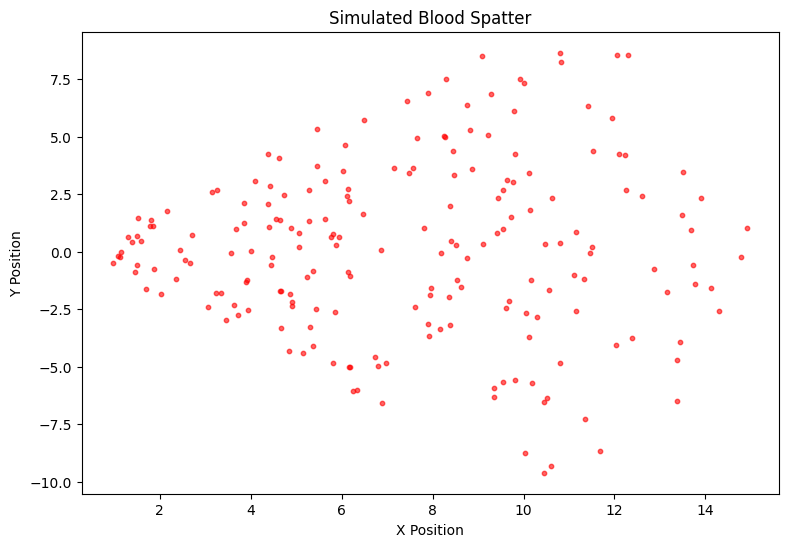

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def generate_blood_spatter(num_drops=100, origin=(0, 0), max_velocity=10, spread=30):
    """Simulates blood spatter using random angles and velocities."""
    x_points, y_points = [], []
    
    for _ in range(num_drops):
        # Random velocity
        velocity = np.random.uniform(1, max_velocity)
        
        # Random impact angle (in degrees, then converted to radians)
        angle = np.random.uniform(-spread, spread) * (np.pi / 180)
        
        # Compute x, y displacement (assuming flat surface impact)
        x = origin[0] + velocity * np.cos(angle)
        y = origin[1] + velocity * np.sin(angle)
        
        x_points.append(x)
        y_points.append(y)
    
    return x_points, y_points

# Generate and plot blood spatter
x, y = generate_blood_spatter(num_drops=200, max_velocity=15, spread=45)
plt.figure(figsize=(9, 6))
plt.scatter(x, y, color='red', alpha=0.6, s=10)
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("Simulated Blood Spatter")
plt.show()

### What type of data did we just simulate?

The simulation involved:
- A single origin point → Suggests a localized source, which could be a wound.
- Randomized velocities (1–15 m/s) → Simulates different impact forces.
- Random spread angles ($\pm45^{\circ}$) → Creates a medium-width distribution.

Looking at these parameters, the generated pattern resembles:
* Impact Spatter rather than passive dripping.
* Medium-velocity spatter (based on velocity range).
* A possible blunt force or stabbing rather than a high-energy gunshot.

If we wanted to simulate data for, say a gunshot wound, we can modify the code by increasing velocity range (30-100 m/s), reduce droplet size and narrow the spread angle ($\pm15^{\circ}$)

### Extracting Insights from Blood Spatter

We need to analyze and understand the simulated spatter data.

The key analyses in this step involve:
1. **Droplet Size Distribution** – How large are the stains? (Histogram, mean, variance)
2. **Velocity vs. Distance Relationship** – Do faster droplets travel farther? (Scatter plot, correlation)
3. **Impact Angle Estimation** – Use trigonometry to estimate the angle of impact
4. **Find the Source of Blood (Reverse Engineering)** – Use trigonometry & geometry

Using python, we generate a code to analyze the first three then proceed to reverse engineering.

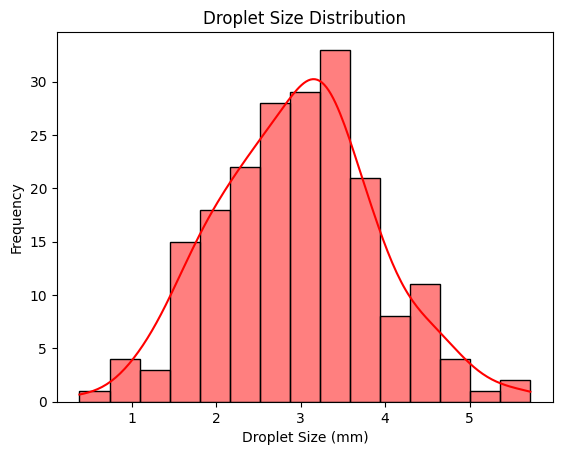

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic blood spatter data
np.random.seed(42)
num_drops = 200

drop_sizes = np.random.normal(loc=3, scale=1, size=num_drops)  # Mean 3mm, Std 1mm
velocities = np.random.uniform(2, 20, num_drops)  # Velocity range from 2-20 m/s
distances = velocities * np.random.uniform(0.5, 1.5, num_drops)  # Distance depends on velocity
angles = np.arcsin(drop_sizes / (drop_sizes + np.random.uniform(1, 5, num_drops))) * (180 / np.pi)  # Impact angles

# --- Plot 1: Droplet Size Distribution ---
sns.histplot(drop_sizes, bins=15, kde=True, color='red')
plt.xlabel('Droplet Size (mm)')
plt.ylabel('Frequency')
plt.title('Droplet Size Distribution')
plt.show()

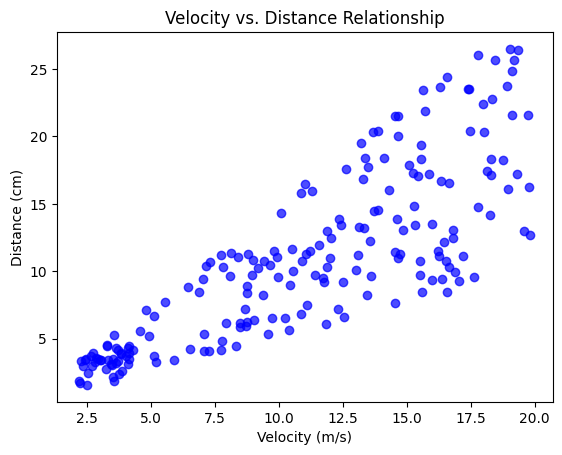

In [4]:

# --- Plot 2: Velocity vs. Distance Relationship ---
plt.scatter(velocities, distances, alpha=0.7, color='blue')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Distance (cm)')
plt.title('Velocity vs. Distance Relationship')
plt.show()


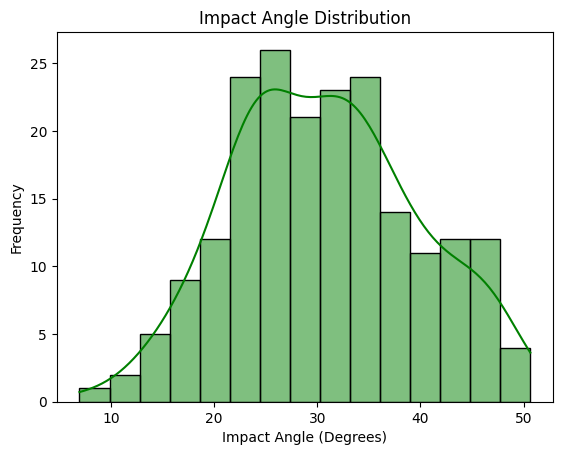

In [5]:

# --- Plot 3: Impact Angle Estimation ---
sns.histplot(angles, bins=15, kde=True, color='green')
plt.xlabel('Impact Angle (Degrees)')
plt.ylabel('Frequency')
plt.title('Impact Angle Distribution')
plt.show()

In [6]:
# Correlation Analysis
corr = np.corrcoef(velocities, distances)[0, 1]
print(f"Correlation between Velocity and Distance: {corr:.2f}")

Correlation between Velocity and Distance: 0.83


Now that we have explored the Droplet size, Velocity vs Distance and the Impact angle, lets try and estimate the source of the spatter by reverse engineering based on the impact angle and distances

Estimated Blood Source Location: X = 10.87 cm, Y = 6.62 cm


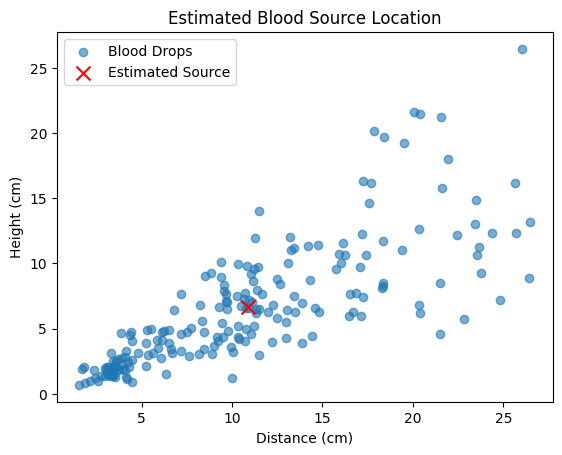

In [9]:
# --- Reverse Engineering Blood Source ---
heights = distances * np.tan(np.radians(angles))

def find_origin(distances, angles):
    heights = distances * np.tan(np.radians(angles))  # Estimate height of impact
    avg_origin_x = np.mean(distances)
    avg_origin_y = np.mean(heights)
    return avg_origin_x, avg_origin_y

origin_x, origin_y = find_origin(distances, angles)
print(f"Estimated Blood Source Location: X = {origin_x:.2f} cm, Y = {origin_y:.2f} cm")

# Visualizing estimated blood source
plt.scatter(distances, heights, alpha=0.6, label='Blood Drops')
plt.scatter(origin_x, origin_y, color='red', marker='x', s=100, label='Estimated Source')
plt.xlabel('Distance (cm)')
plt.ylabel('Height (cm)')
plt.title('Estimated Blood Source Location')
plt.legend()
plt.show()

**What have we done?**

1. The height of impact is estimated using trigonometry;

$$Height = Distance * \tan(Impact Angle)$$

2. Calculated the average position of the estimated origin (X,Y)
3. Plotted the blood spatter and marked the estimated origin in red (X)

## Machine Learning Approach to Blood Spatter Analysis
**Objective**
In this section, we apply K-Means clustering, an unsupervised machine learning technique, to analyze blood spatter patterns. The goal is to identify natural groupings within the data based on key characteristics such as distance from the source and impact angle. This can help forensic investigators classify different bloodstain patterns, potentially distinguishing between different types of impact forces or sources.

**Why K-Means Clustering?**
We chose K-Means clustering for the following reasons:

- *Unsupervised Learning*: Since we don't have predefined labels for the bloodstain data, clustering helps us discover hidden structures.
- *Efficiency*: K-Means is computationally efficient, making it suitable for large forensic datasets.
- *Interpretability*: By visualizing clusters, we can infer different impact dynamics and blood spatter sources.

**Methodology**
1. Feature Selection: We used two key features for clustering:
   - *Distance from the source (cm)*: Helps differentiate between high-velocity vs. low-velocity spatters.
   - *Impact Angle (degrees)*: Indicates the trajectory and nature of impact.
2. K-Means Algorithm:
- We set the number of clusters to three (k=3) based on expected variations in spatter patterns.
- The algorithm assigns each bloodstain to the nearest cluster center.
- We visualize the results using a scatter plot, where different colors represent distinct clusters.
Results & Interpretation
The clustering process groups the blood spatters based on similar impact angles and distances.
Distinct clusters suggest variations in blood spatter, which could correspond to:
Low-velocity impact (e.g., blunt force trauma)
Medium-velocity impact (e.g., stabbing or beating)
High-velocity impact (e.g., gunshot wounds)
If needed, we can fine-tune the clustering by adjusting k (number of clusters) or incorporating additional features like droplet size or velocity.

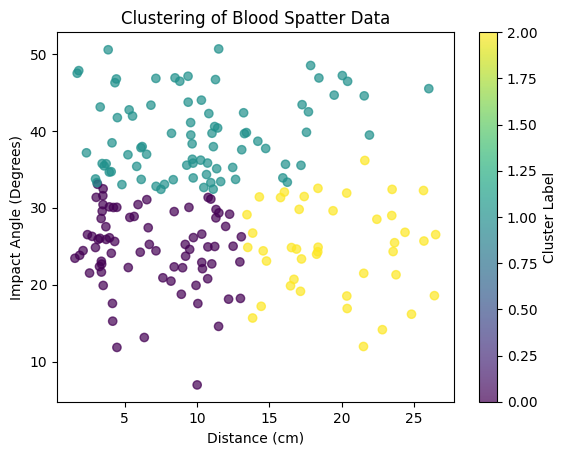

In [11]:
from sklearn.cluster import KMeans

# --- Clustering Blood Spatter Data ---
data_points = np.column_stack((distances, angles))
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(data_points)
labels = kmeans.labels_

# Visualizing Clusters
plt.scatter(distances, angles, c=labels, cmap='viridis', alpha=0.7)
plt.xlabel('Distance (cm)')
plt.ylabel('Impact Angle (Degrees)')
plt.title('Clustering of Blood Spatter Data')
plt.colorbar(label='Cluster Label')
plt.show()

**Results & Interpretation**

- The clustering process groups the blood spatters based on similar impact angles and distances.
- Distinct clusters suggest variations in blood spatter, which could correspond to:
1. Low-velocity impact (e.g., blunt force trauma)
2. Medium-velocity impact (e.g., stabbing or beating)
3. High-velocity impact (e.g., gunshot wounds)
If needed, we can fine-tune the clustering by adjusting k (number of clusters) or incorporating additional features like droplet size or velocity.

## Assumptions in Blood Spatter Analysis

Blood spatter analysis relies on several fundamental assumptions to interpret the patterns left at a crime scene. These assumptions form the basis for reconstructing events based on bloodstain evidence.

1. Blood Follows Predictable Physical Laws: 
Blood droplets behave as projectiles, governed by Newtonian physics. Once a blood droplet leaves the source, it is primarily influenced by gravity, velocity, air resistance, and surface tension. The trajectory and final resting position of the droplet can be predicted using standard physics equations.

2. Droplet Shape and Size Correlate with Force and Impact:
The size of blood droplets depends on the velocity of impact:
- Low-velocity impact (e.g., blunt force trauma) produces larger, more concentrated stains.
- Medium-velocity impact (e.g., beating, stabbing) results in smaller and more dispersed droplets.
- High-velocity impact (e.g., gunshot wounds) creates fine mist-like spatter.

Larger stains typically indicate lower-energy events, while smaller stains suggest higher-energy impacts.

3. Impact Angle Can Be Estimated Using Geometry: 
Blood droplets striking a surface at an angle form an elliptical shape. The angle of impact ($\theta$) can be calculated using the width-to-length ratio of the stain:
$$\theta=arcsin\left(\frac{width}{length}\right)$$
A more elongated stain suggests a shallower impact angle, while a nearly circular stain indicates a perpendicular impact.

4. Bloodstain Clustering Represents Different Sources or Events:
Bloodstains at a crime scene are often grouped into clusters based on their properties. These clusters may correspond to different:
- *Impact events* (e.g., multiple strikes or shots).
- *Sources* (e.g., victim vs. suspect blood).
- *Forces applied* (e.g., gunshot vs. blunt force trauma).

5. Blood Source Estimation Assumes a Common Origin:
Analysts often use trigonometry to estimate the point of origin of a blood spatter event. This assumes that all stains in a given pattern originate from one specific source. However, movement or multiple impacts may complicate the actual distribution of stains.

6. Surface Type Affects Spatter Behavior:
The surface that blood lands on plays a critical role in determining stain shape and distribution. Smooth, non-porous surfaces (e.g., glass, tile) produce well-defined stains with minimal distortion. Rough or absorbent surfaces (e.g., fabric, carpet) cause irregular stains due to absorption and surface tension effects.

7. Blood Patterns Can Be Reverse Engineered:
By analyzing bloodstains, forensic experts assume they can trace back to the event that caused the pattern. This involves using mathematical models to estimate factors like height of impact, velocity, and point of origin. While reliable, external factors such as secondary impacts, smudging, or additional forces can introduce uncertainty.

In conclusion, blood spatter analysis is a powerful forensic tool, but it relies on fundamental assumptions about physics, biology, and geometry. Understanding these assumptions allows forensic investigators to interpret crime scenes accurately while also recognizing potential limitations and uncertainties in their findings.

## Conclusion
In this report, we explored the principles of blood spatter analysis, from understanding its forensic significance to simulating and analyzing synthetic bloodstain data. Using machine learning techniques, particularly K-Means clustering, we identified distinct patterns within the data, demonstrating how computational methods can aid forensic investigations.

Our study reaffirmed several key principles in blood spatter analysis:

- Blood droplet size and velocity correlate with the force applied at the source.
- Impact angle estimation allows for the reconstruction of possible crime scene events.
- Clustering techniques help distinguish between different spatter patterns, potentially separating multiple impact events or different sources of blood.

### Implications and Limitations
The application of data science and machine learning in forensic analysis holds great promise for improving the accuracy of crime scene reconstructions. However, there are limitations:

- Environmental factors (e.g., air resistance, surface properties) may introduce variability that is difficult to model.
- Human movement and secondary transfer can complicate interpretations.
- Machine learning models require large, real-world datasets to enhance accuracy beyond simulations.

### Future Work
To improve upon this analysis, future studies could:

- Use supervised learning techniques to classify bloodstain patterns with labeled forensic data.
- Incorporate 3D reconstruction methods for more precise origin estimations.
- Validate results with real forensic cases to assess model reliability in actual crime scene investigations.

By bridging forensic science with machine learning, this study highlights the potential of computational tools in crime scene analysis. While challenges remain, continued advancements in data-driven forensics will undoubtedly enhance the precision and reliability of blood spatter interpretation.